<a href="https://colab.research.google.com/github/dzidz1/Freeuni_ML_Walmart_Sales_Forecasting/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Walmart Recruiting — Store Sales Forecasting
## Data Analysis (EDA)

## 1. Setup

In [1]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## 2. Download the data from Kaggle

In [2]:
import os
from google.colab import userdata

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_KEY')

!kaggle competitions download -c walmart-recruiting-store-sales-forecasting

walmart-recruiting-store-sales-forecasting.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
os.makedirs('walmart_data', exist_ok=True)

with zipfile.ZipFile('walmart-recruiting-store-sales-forecasting.zip') as z:
    z.extractall('walmart_data')

for f in os.listdir('walmart_data'):
    if f.endswith('.zip'):
        with zipfile.ZipFile(os.path.join('walmart_data', f)) as z:
            z.extractall('walmart_data')

print(os.listdir('walmart_data'))

['train.csv', 'test.csv', 'test.csv.zip', 'features.csv.zip', 'train.csv.zip', 'sampleSubmission.csv.zip', 'stores.csv', 'sampleSubmission.csv', 'features.csv']


## 3. Load the files

In [4]:
train    = pd.read_csv('walmart_data/train.csv',    parse_dates=['Date'])
test     = pd.read_csv('walmart_data/test.csv',     parse_dates=['Date'])
features = pd.read_csv('walmart_data/features.csv', parse_dates=['Date'])
stores   = pd.read_csv('walmart_data/stores.csv')

for name, d in [('train', train), ('test', test), ('features', features), ('stores', stores)]:
    print(f'{name:9s}{d.shape}')

train    (421570, 5)
test     (115064, 4)
features (8190, 12)
stores   (45, 3)


## 4. First look

In [5]:
display(train.head())
display(stores.head())

print("Date range :", train['Date'].min().date(), "→", train['Date'].max().date())
print("Stores     :", train['Store'].nunique())
print("Departments:", train['Dept'].nunique())
print("Series     :", train.groupby(['Store', 'Dept']).ngroups, "(Store-Dept combinations)")

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


Date range : 2010-02-05 → 2012-10-26
Stores     : 45
Departments: 81
Series     : 3331 (Store-Dept combinations)


## 5. Merge into one analysis table

In [6]:
df = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
df = df.merge(stores, on='Store', how='left')

print("Merged shape:", df.shape)
df.head()

Merged shape: (421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


## 6. Sanity checks

In [7]:
print("Duplicate Store-Dept-Date rows:", df.duplicated(subset=['Store', 'Dept', 'Date']).sum())
print("Negative Weekly_Sales rows    :", (df['Weekly_Sales'] < 0).sum())

print("\nMissing values per column:")
print(df.isna().sum())

Duplicate Store-Dept-Date rows: 0
Negative Weekly_Sales rows    : 1285

Missing values per column:
Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64


## 7. Target variable: `Weekly_Sales`

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64


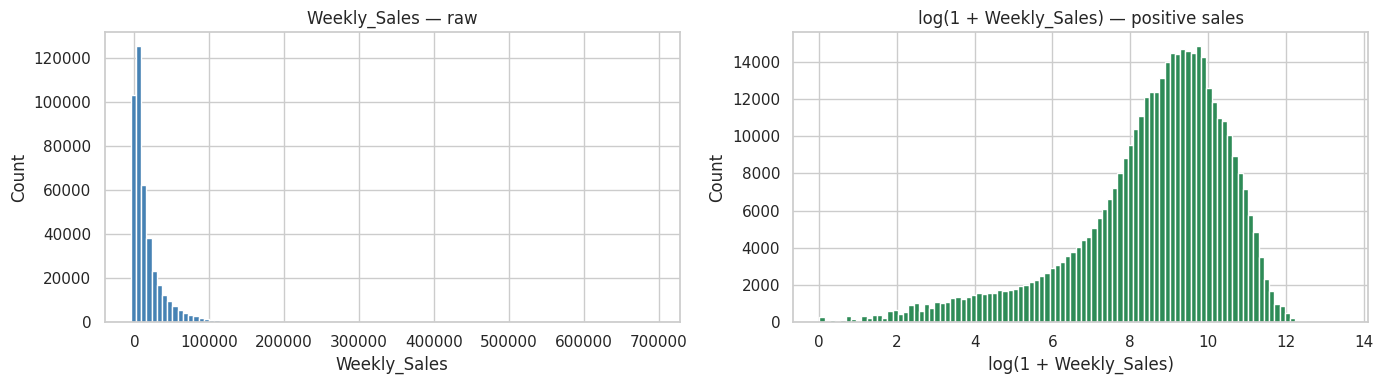

Skewness (raw)      : 3.26
Skewness (log1p pos): -1.2


In [8]:
print(df['Weekly_Sales'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Weekly_Sales'], bins=100, color='steelblue')
axes[0].set_title('Weekly_Sales — raw')
axes[0].set_xlabel('Weekly_Sales'); axes[0].set_ylabel('Count')

# log1p handles zeros; we look only at positive sales for the log view
pos = df.loc[df['Weekly_Sales'] > 0, 'Weekly_Sales']
axes[1].hist(np.log1p(pos), bins=100, color='seagreen')
axes[1].set_title('log(1 + Weekly_Sales) — positive sales')
axes[1].set_xlabel('log(1 + Weekly_Sales)'); axes[1].set_ylabel('Count')

plt.tight_layout(); plt.show()

print("Skewness (raw)      :", round(df['Weekly_Sales'].skew(), 2))
print("Skewness (log1p pos):", round(np.log1p(pos).skew(), 2))

### 7.1 The negative sales

In [9]:
neg = df[df['Weekly_Sales'] < 0]
print("Negative rows :", len(neg), f"({100*len(neg)/len(df):.2f}% of data)")
print("Most negative :", round(df['Weekly_Sales'].min(), 2))
print("Departments with most negatives:")
print(neg['Dept'].value_counts().head(10))

Negative rows : 1285 (0.30% of data)
Most negative : -4988.94
Departments with most negatives:
Dept
47    254
18    180
54    146
19     87
94     77
80     68
49     67
59     44
72     34
78     33
Name: count, dtype: int64


### 7.2 Takeaway
`Weekly_Sales` is strongly right-skewed (3.26); log(1+sales) makes it roughly
symmetric (−1.2). Useful to test for neural models, not needed for trees.
Negatives are rare (0.30%, min −4,988.94) and concentrated in a few
return-prone departments — we keep them.

## 8. Temporal patterns and seasonality

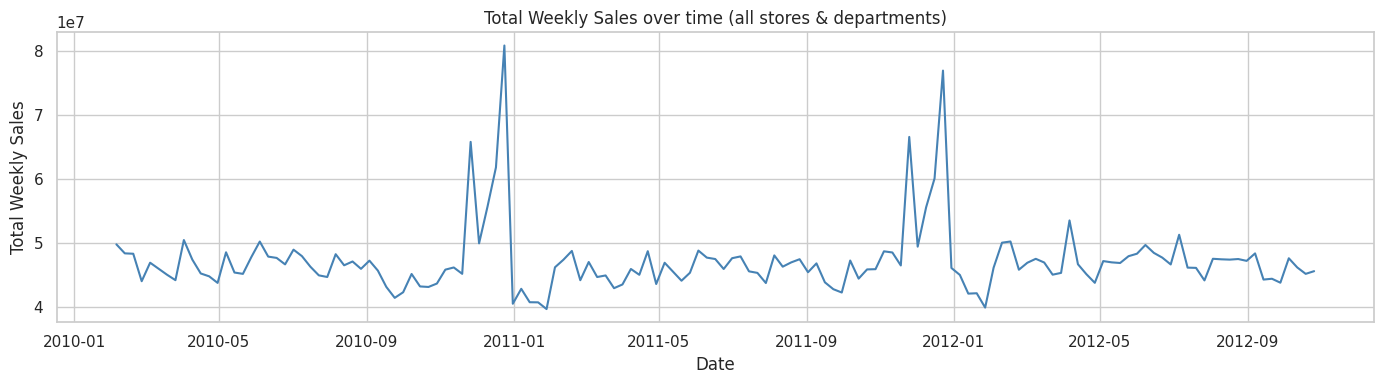

In [10]:
weekly_total = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(14, 4))
plt.plot(weekly_total.index, weekly_total.values, color='steelblue')
plt.title('Total Weekly Sales over time (all stores & departments)')
plt.xlabel('Date'); plt.ylabel('Total Weekly Sales')
plt.tight_layout(); plt.show()

### 8.1 Seasonality by month and week-of-year

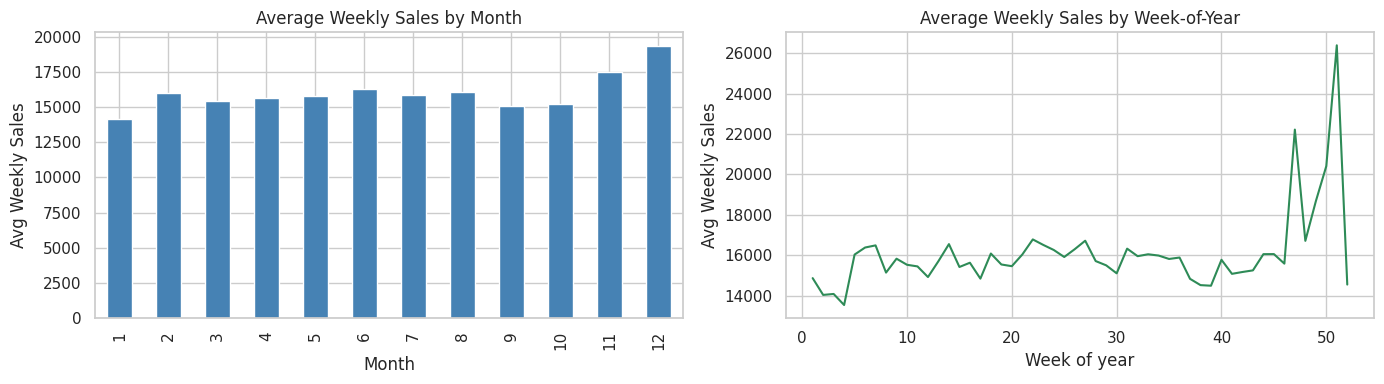

In [11]:
df['Month'] = df['Date'].dt.month
df['Week']  = df['Date'].dt.isocalendar().week.astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby('Month')['Weekly_Sales'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average Weekly Sales by Month')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Avg Weekly Sales')

df.groupby('Week')['Weekly_Sales'].mean().plot(ax=axes[1], color='seagreen')
axes[1].set_title('Average Weekly Sales by Week-of-Year')
axes[1].set_xlabel('Week of year'); axes[1].set_ylabel('Avg Weekly Sales')

plt.tight_layout(); plt.show()

### 8.2 Takeaway
Sales are flat (~15k/week avg) most of the year, then spike sharply in
weeks 47–52 — peaking near Christmas at ~26k. The peak is narrow (a few
specific weeks), not a smooth seasonal hump, so discrete week-of-year and
holiday flags will capture it better than a broad "month" feature.

## 9. The holiday effect

In [12]:
# Overall holiday vs non-holiday
holiday_means = df.groupby('IsHoliday')['Weekly_Sales'].agg(['mean', 'median', 'count'])
print(holiday_means)

lift = holiday_means.loc[True, 'mean'] / holiday_means.loc[False, 'mean'] - 1
print(f"\nHoliday weeks average {lift*100:.1f}% higher than non-holiday weeks")

                   mean   median   count
IsHoliday                               
False      15901.445069  7589.95  391909
True       17035.823187  7947.74   29661

Holiday weeks average 7.1% higher than non-holiday weeks


### 9.1 By specific holiday

In [13]:
# The four holidays are identified by their known dates in the data
holiday_dates = {
    'Super Bowl':   ['2010-02-12', '2011-02-11', '2012-02-10'],
    'Labor Day':    ['2010-09-10', '2011-09-09', '2012-09-07'],
    'Thanksgiving': ['2010-11-26', '2011-11-25', '2012-11-23'],
    'Christmas':    ['2010-12-31', '2011-12-30', '2012-12-28'],
}

date_to_holiday = {pd.Timestamp(d): name for name, dates in holiday_dates.items() for d in dates}
df['HolidayName'] = df['Date'].map(date_to_holiday).fillna('None')

baseline = df.loc[df['HolidayName'] == 'None', 'Weekly_Sales'].mean()
summary = df.groupby('HolidayName')['Weekly_Sales'].mean().sort_values(ascending=False)

print("Average Weekly Sales by holiday (baseline 'None' for reference):\n")
for name, val in summary.items():
    lift = val / baseline - 1
    print(f"{name:13s} {val:9.0f}   ({lift*+100:+.1f}% vs baseline)")

Average Weekly Sales by holiday (baseline 'None' for reference):

Thanksgiving      22221   (+39.7% vs baseline)
Super Bowl        16378   (+3.0% vs baseline)
None              15901   (+0.0% vs baseline)
Labor Day         15882   (-0.1% vs baseline)
Christmas         14543   (-8.5% vs baseline)


### 9.2 Why is Christmas below baseline? The flag is misaligned
The `IsHoliday` flag marks the week ending near the holiday. For Christmas,
that week falls after Dec 25 — the gift-buying surge is the week before it,
which carries no holiday flag. We check the weeks around year-end to confirm.

In [14]:
wk = df.groupby('Week')['Weekly_Sales'].mean()
print("Average Weekly Sales by week-of-year (year-end run-up):")
print(wk.loc[[47, 48, 49, 50, 51, 52]].round(0))

Average Weekly Sales by week-of-year (year-end run-up):
Week
47    22221.0
48    16709.0
49    18669.0
50    20413.0
51    26396.0
52    14543.0
Name: Weekly_Sales, dtype: float64


### 9.3 Takeaway
`IsHoliday` is a weak feature: it nets +7.1% by averaging Black Friday
(week 47, 22,221) against the flagged Christmas week (week 52, 14,543 — a
trough). The real peak is week 51 (26,396), which carries no holiday flag.
So we engineer per-holiday identity + days-to/from-holiday proximity, not one
binary flag — and it matters 5x under WMAE.

## 10. Store and department effects

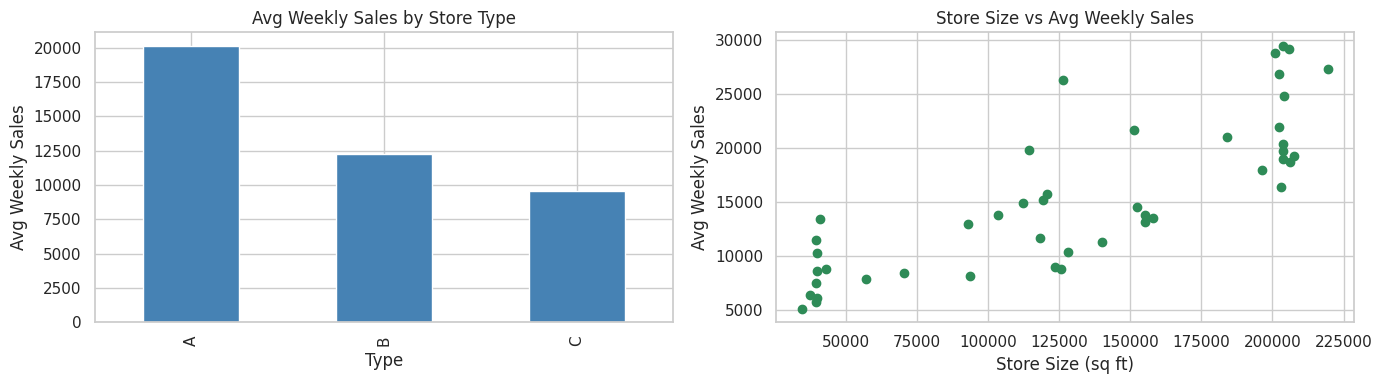

              mean    median   count
Type                                
A     20099.568043  10105.17  215478
B     12237.075977   6187.87  163495
C      9519.532538   1149.67   42597


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Average weekly sales by store Type
df.groupby('Type')['Weekly_Sales'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Avg Weekly Sales by Store Type')
axes[0].set_xlabel('Type'); axes[0].set_ylabel('Avg Weekly Sales')

# Store Size vs average sales (one point per store)
store_stats = df.groupby('Store').agg(avg_sales=('Weekly_Sales','mean'),
                                       size=('Size','first'),
                                       type=('Type','first'))
axes[1].scatter(store_stats['size'], store_stats['avg_sales'], c='seagreen')
axes[1].set_title('Store Size vs Avg Weekly Sales')
axes[1].set_xlabel('Store Size (sq ft)'); axes[1].set_ylabel('Avg Weekly Sales')

plt.tight_layout(); plt.show()

print(df.groupby('Type')['Weekly_Sales'].agg(['mean','median','count']))

### 10.1 Takeaway
Store Type strictly orders sales (A 20,099 > B 12,237 > C 9,519), and the
scatter shows this is driven by Size — bigger stores sell more, with Type A
the large-format stores. Type and Size are partly redundant.

Top 10 departments by average sales:
         mean      std
Dept                  
92    75205.0  49414.0
95    69824.0  38201.0
38    61091.0  23967.0
72    50567.0  44711.0
65    45442.0   7087.0
90    45232.0  32462.0
40    44901.0  21904.0
2     43607.0  25177.0
91    33688.0  26247.0
94    33406.0  25406.0


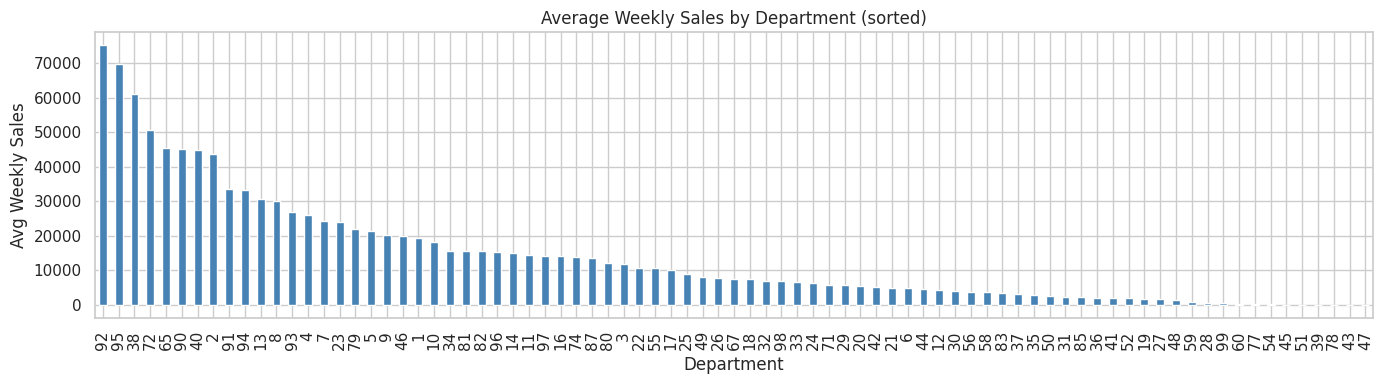

In [16]:
# Department spread: which departments are largest and most variable
dept_stats = df.groupby('Dept')['Weekly_Sales'].agg(['mean','std']).sort_values('mean', ascending=False)
print("Top 10 departments by average sales:")
print(dept_stats.head(10).round(0))

plt.figure(figsize=(14, 4))
df.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Average Weekly Sales by Department (sorted)')
plt.xlabel('Department'); plt.ylabel('Avg Weekly Sales')
plt.tight_layout(); plt.show()

### 10.2 Takeaway
Departments span a huge range (~75,205 down to near-zero) with very different
volatility (Dept 92 std ≈ 49k vs Dept 65 ≈ 7k). Per-store and per-department
sales statistics (mean/std/median) will be strong features — the model needs
to know each series' baseline level and stability.

## 11. External features vs sales

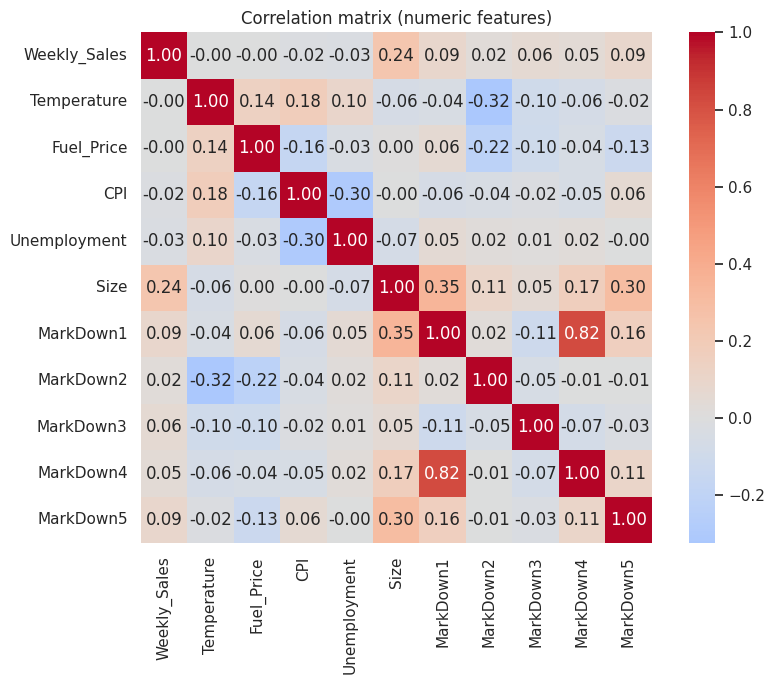

Correlation with Weekly_Sales (sorted):
Size            0.244
MarkDown5       0.090
MarkDown1       0.085
MarkDown3       0.060
MarkDown4       0.045
MarkDown2       0.024
Fuel_Price     -0.000
Temperature    -0.002
CPI            -0.021
Unemployment   -0.026
Name: Weekly_Sales, dtype: float64


In [17]:
num_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI',
            'Unemployment', 'Size',
            'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation matrix (numeric features)')
plt.tight_layout(); plt.show()

print("Correlation with Weekly_Sales (sorted):")
print(corr['Weekly_Sales'].drop('Weekly_Sales').sort_values(ascending=False).round(3))

### 11.1 Takeaway
No external variable is a strong linear predictor: Size leads at just 0.24,
markdowns are mild (0.02–0.09), and Temperature/Fuel/CPI/Unemployment are ~0.
MarkDown1 and MarkDown4 are 0.82 correlated (redundant). Low linear correlation
≠ useless — value comes via engineered forms (ratios, intensity, lags), not raw
columns. Lag/rolling features of past sales will outweigh all of these.

## 12. Autocorrelation (ACF / PACF)


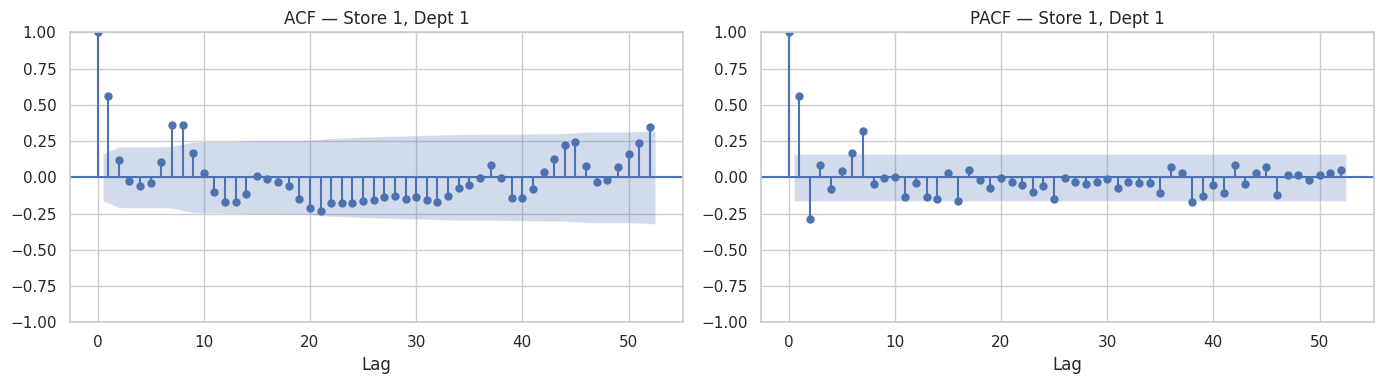

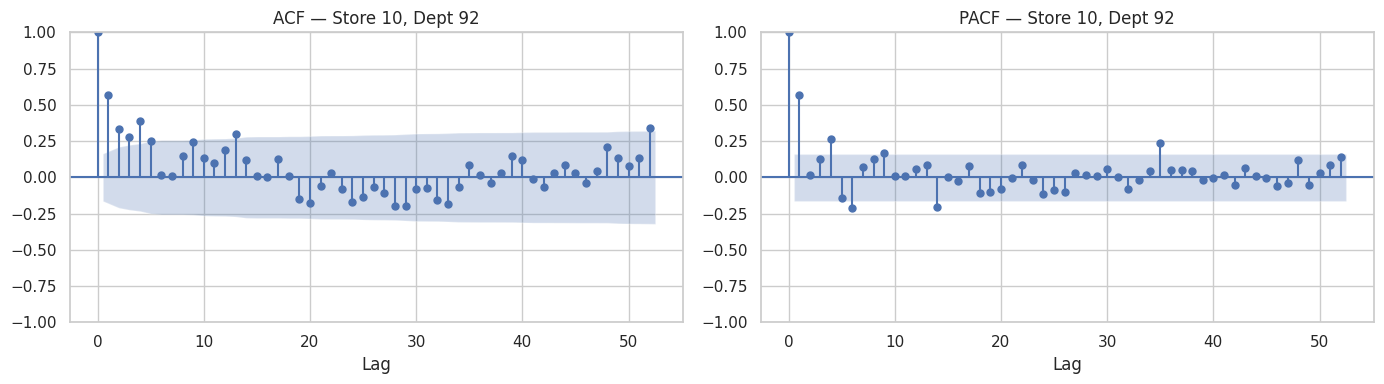

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_acf_pacf(store_id, dept_id, lags=52):
    s = (df[(df['Store'] == store_id) & (df['Dept'] == dept_id)]
         .sort_values('Date')['Weekly_Sales'])
    if len(s) <= lags:
        print(f"Store {store_id}, Dept {dept_id}: too short ({len(s)} weeks)"); return

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(s,  lags=lags, ax=axes[0], title=f'ACF — Store {store_id}, Dept {dept_id}')
    plot_pacf(s, lags=lags, ax=axes[1], title=f'PACF — Store {store_id}, Dept {dept_id}')
    axes[0].set_xlabel('Lag'); axes[1].set_xlabel('Lag')
    plt.tight_layout(); plt.show()

plot_acf_pacf(1, 1)     # a typical series
plot_acf_pacf(10, 92)   # a large, high-volume department

### 12.1 Takeaway
ACF is high at lag 1 (~0.6) and decays slowly, with a clear rise back toward
lag 52 — confirming both weekly persistence and yearly seasonality. PACF spikes
at lags 1-3 then drops inside the significance band, so short lags hold the
direct signal. We engineer lag 1-3 (short-term) and lag 52 (yearly) features,
plus rolling means.